In [1]:
import scipy 
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import os

from dpd_baselines.utils.data_loader import BlackBoxData80Loader
from dpd_baselines.models.Hammershtain_model import Hammershtain

dpd_baseline_path = Path(r'D:\github_projects\dpd-baselines')
os.chdir(dpd_baseline_path)
signal_path = Path(r'data\BlackBoxData_80.mat')

fs = 1.2288e6
data = BlackBoxData80Loader(signal_path, seq_len=2**10)
data.normalize()
# BL_coeff = data.apply_bl()
x_t, y_t, _ = data.get_signals()



(-170.0, -50.0)

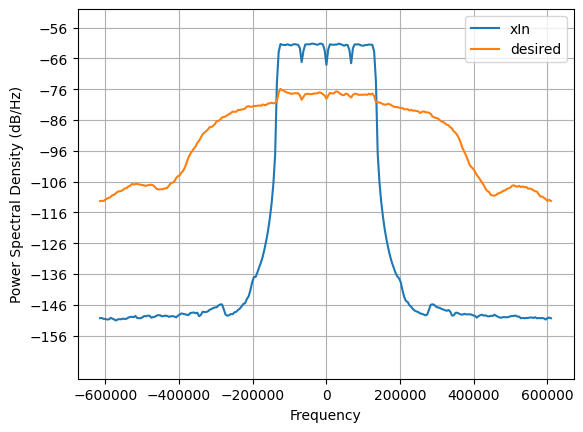

In [2]:
plt.psd(x_t.detach().reshape(-1).numpy(), Fs = fs, label='xIn')
plt.psd(y_t.detach().reshape(-1).numpy(), Fs = fs, label='desired')
# plt.psd(x_t.detach().reshape(-1).numpy() + y_t.detach().reshape(-1).numpy(), Fs = fs, label='yOut');
plt.legend()
plt.ylim(-170, -50)

(-170.0, -50.0)

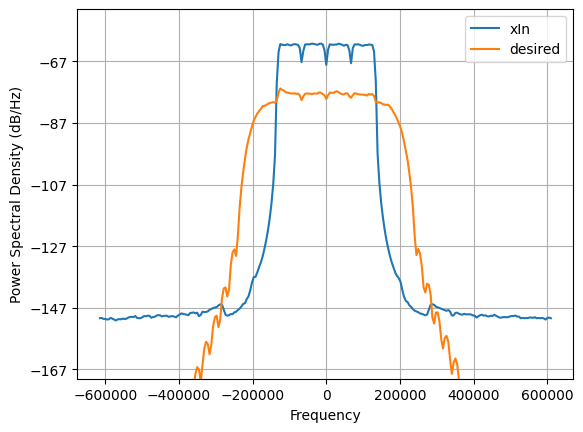

In [3]:
BL_coeff = data.apply_bl(numtaps=50)
x_t, y_t, _ = data.get_signals()

plt.psd(x_t.detach().reshape(-1).numpy(), Fs = fs, label='xIn')
plt.psd(y_t.detach().reshape(-1).numpy(), Fs = fs, label='desired')
# plt.psd(x_t.detach().reshape(-1).numpy() + y_t.detach().reshape(-1).numpy(), Fs = fs, label='yOut');
plt.legend()
plt.ylim(-170, -50)

Text(0, 0.5, 'Amplitude Out')

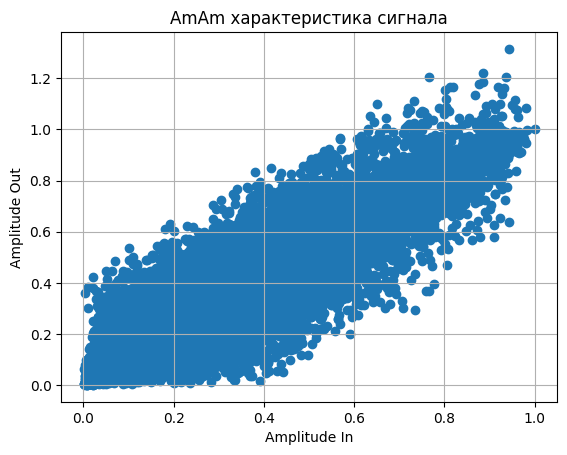

In [4]:
x_numpy = x_t.detach().reshape(-1).numpy()
out_numpy = x_t.detach().reshape(-1).numpy() + y_t.detach().reshape(-1).numpy()
plt.scatter(np.abs(x_numpy), np.abs(out_numpy));
plt.title('AmAm характеристика сигнала')
plt.grid(True)
plt.xlabel('Amplitude In')
plt.ylabel('Amplitude Out')

In [5]:
device = 'cpu'
epochs = 100
lr = 2**-3
n_train = int(x_t.shape[0])
batch_size = 8

model = Hammershtain([0], [3], 2, BL_coeff=BL_coeff)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def nmse(y_hat, y_true, ref, eps=1e-12):
    err = (y_hat - y_true).abs().pow(2).mean()
    ref = ref.abs().pow(2).mean()
    return 10*torch.log10(err / (ref + eps))

def mse(y_hat, y_true):
    err = (y_hat - y_true).abs().pow(2).mean()
    return err 
    


for epoch in range(1, epochs + 1):
    running = 0.0
    steps = 0

    for i in range(0, n_train, batch_size):
        xb = x_t[i : i + batch_size].to(device)  
        yb = y_t[i : i + batch_size].to(device)

        optimizer.zero_grad()
        y_hat = model(xb)                
        loss = mse(y_hat, yb)
        loss.backward()
        optimizer.step()

        running += float(loss.detach().cpu())
        steps += 1

    train_loss = running / max(1, steps)
    model.eval()
    with torch.no_grad():
        y_hat = model(x_t)
        val_loss = float(nmse(y_hat, y_t, ref=x_t).cpu())
    model.train()
    print(f"epoch {epoch:02d} | mse={train_loss:.3f} | NMSE={val_loss:.3f}")
    

epoch 01 | mse=0.008 | NMSE=-14.475
epoch 02 | mse=0.003 | NMSE=-21.473
epoch 03 | mse=0.001 | NMSE=-21.948
epoch 04 | mse=0.001 | NMSE=-24.030
epoch 05 | mse=0.001 | NMSE=-24.560
epoch 06 | mse=0.001 | NMSE=-24.862
epoch 07 | mse=0.001 | NMSE=-24.973
epoch 08 | mse=0.001 | NMSE=-25.036
epoch 09 | mse=0.001 | NMSE=-25.089
epoch 10 | mse=0.001 | NMSE=-25.134
epoch 11 | mse=0.001 | NMSE=-25.170
epoch 12 | mse=0.001 | NMSE=-25.202
epoch 13 | mse=0.001 | NMSE=-25.230
epoch 14 | mse=0.001 | NMSE=-25.256
epoch 15 | mse=0.001 | NMSE=-25.280
epoch 16 | mse=0.001 | NMSE=-25.301
epoch 17 | mse=0.001 | NMSE=-25.320
epoch 18 | mse=0.001 | NMSE=-25.338
epoch 19 | mse=0.000 | NMSE=-25.354
epoch 20 | mse=0.000 | NMSE=-25.368
epoch 21 | mse=0.000 | NMSE=-25.381
epoch 22 | mse=0.000 | NMSE=-25.393
epoch 23 | mse=0.000 | NMSE=-25.404
epoch 24 | mse=0.000 | NMSE=-25.415
epoch 25 | mse=0.000 | NMSE=-25.425
epoch 26 | mse=0.000 | NMSE=-25.436
epoch 27 | mse=0.000 | NMSE=-25.446
epoch 28 | mse=0.000 | NMSE=

Text(0, 0.5, 'Amplitude Out')

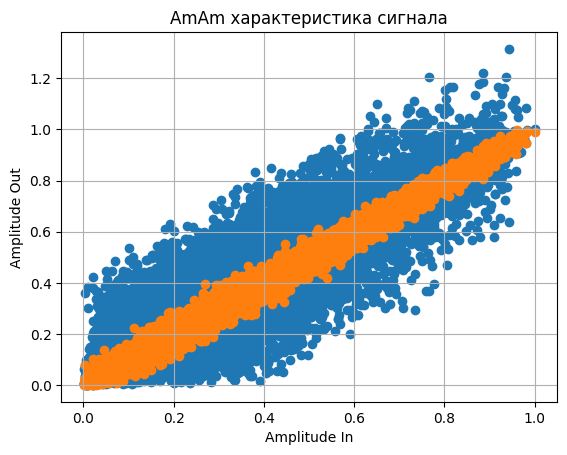

In [6]:
with torch.no_grad():
    y_hat = model(x_t)
    val_loss = float(nmse(y_hat, y_t, ref=x_t).cpu())

y_hat_numpy = y_hat.detach().reshape(-1).numpy()
y_or_numpy = y_t.detach().reshape(-1).numpy()

plt.scatter(np.abs(x_numpy), np.abs(out_numpy));
plt.scatter(np.abs(x_numpy), np.abs(x_numpy + y_or_numpy - y_hat_numpy ));
# plt.scatter(np.abs(x_numpy), np.abs(x_numpy));
# plt.scatter(np.abs(x_numpy + y_hat_numpy), np.abs(out_numpy));
plt.title('AmAm характеристика сигнала')
plt.grid(True)
plt.xlabel('Amplitude In')
plt.ylabel('Amplitude Out')

In [7]:
for name, p in model.named_parameters():
    print(name, p.shape, p.dtype, "requires_grad=", p.requires_grad)

fir.h torch.Size([2]) torch.complex64 requires_grad= True
poly_bank.0.p.coeff torch.Size([3]) torch.float32 requires_grad= True


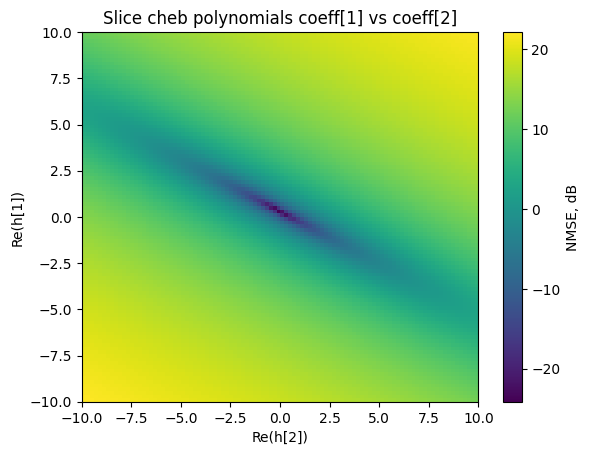

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.as_tensor(x_t, dtype=torch.complex64, device=device)
y = torch.as_tensor(y_t, dtype=torch.complex64, device=device)

model = model.to(device).eval()

@torch.no_grad()
def nmse(y_hat, y_true, ref, eps=1e-12):
    err = (y_hat - y_true).abs().pow(2).mean()
    ref = ref.abs().pow(2).mean()
    return 10*torch.log10(err / (ref + eps))


h = model.poly_bank[0].p.coeff
h0 = h.detach().clone()

grid = np.linspace(-10, 10, 100)
Z = np.zeros((len(grid), len(grid)))

with torch.no_grad():
    for i, a in enumerate(grid):
        for j, b in enumerate(grid):
            h.copy_(h0)
            h[0] = torch.tensor(a, dtype=h.dtype, device=device)
            h[1] = torch.tensor(b, dtype=h.dtype, device=device)
            Z[i, j] = nmse(model(x), y, x).item()

with torch.no_grad():
    h.copy_(h0)
plt.imshow(Z, origin="lower",
           extent=[grid[0], grid[-1], grid[0], grid[-1]],
           aspect="auto")
plt.colorbar(label="NMSE, dB")
plt.xlabel("Re(h[2])")
plt.ylabel("Re(h[1])")
plt.title("Slice cheb polynomials coeff[1] vs coeff[2]")
plt.show()

In [16]:
%matplotlib widget

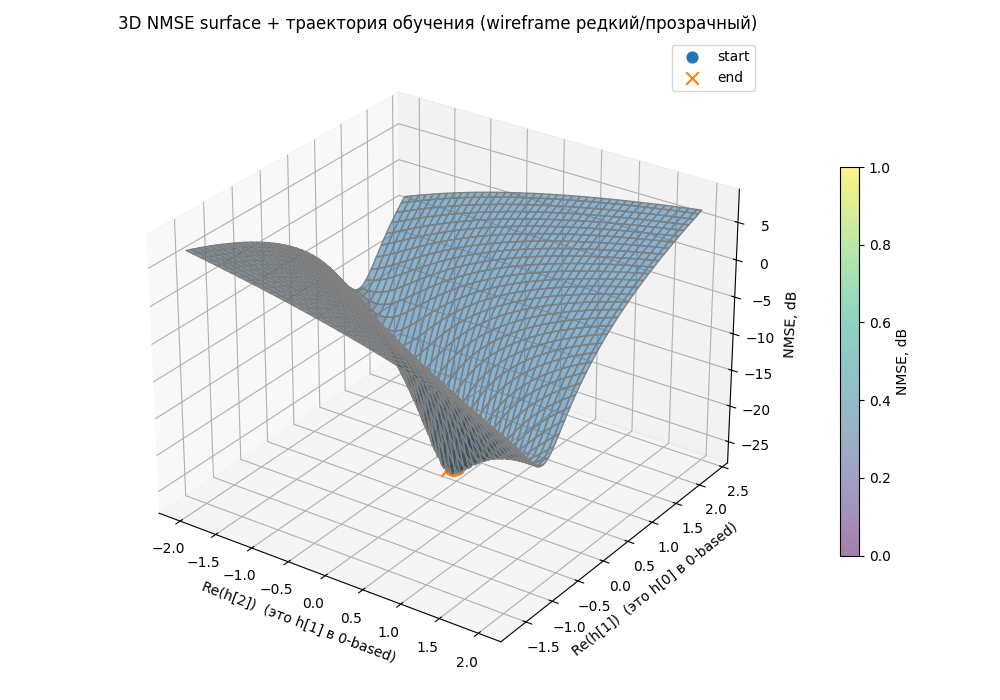

In [30]:
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.close()
model.eval()
h = model.poly_bank[0].p.coeff
h_saved = h.detach().clone()

@torch.no_grad()
def nmse_at_ab(a, b):
    h.copy_(h_saved)
    h[0] = torch.tensor(a, dtype=h.dtype, device=device)
    h[1] = torch.tensor(b, dtype=h.dtype, device=device)
    return float(nmse(model(x), y, ref=x).detach().cpu())

# z для траектории
z_traj = [nmse_at_ab(a, b) for a, b in zip(traj_a, traj_b)]

with torch.no_grad():
    h.copy_(h_saved)

# Сетка
A, B = np.meshgrid(grid_a, grid_b, indexing="ij")  # A ~ y-axis (a), B ~ x-axis (b)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    B, A, Z,
    edgecolor="gray",
    alpha=0.5,
    antialiased=True,
)


divisor = 1000
step = max(1, Z.shape[0] // divisor)

ax.plot_wireframe(
    B[::step, ::step],
    A[::step, ::step],
    Z[::step, ::step],
    color="g",       # одноцветная
    alpha=0.01,      # прозрачная
    linewidth=0.02,
)

# Траектория по поверхности
ax.plot(traj_b, traj_a, z_traj, linewidth=3)
ax.scatter([traj_b[0]], [traj_a[0]], [z_traj[0]], s=60, marker="o", label="start")
ax.scatter([traj_b[-1]], [traj_a[-1]], [z_traj[-1]], s=80, marker="x", label="end")
ax.legend()

# Подписи осей (как у тебя: x=coeff[2], y=coeff[1] в 1-based)
ax.set_xlabel("Re(h[2])  (это h[1] в 0-based)")
ax.set_ylabel("Re(h[1])  (это h[0] в 0-based)")
ax.set_zlabel("NMSE, dB")
ax.set_title("3D NMSE surface + траектория обучения (wireframe редкий/прозрачный)")

ax.view_init(elev=28, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, label="NMSE, dB")

plt.tight_layout()
plt.show()